In [8]:
import metapredict as mp
import pandas as pd
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import statistics
from Bio.SeqUtils import ProtParam

In [9]:
tf = pd.read_csv('Full-DBDs.csv').dropna()
tf.reset_index(inplace=True)

In [10]:
len(tf)

1264

In [12]:

#Individual hydropathy score dictionary
hp ={'A':1.8, 'R':-4.5, 'N':-3.5, 'D':-3.5, 'C': 2.5, 'Q':-3.5, 'E':-3.5,
    'G':-0.4, 'H':-3.2, 'I': 4.5, 'L': 3.8, 'K':-3.9, 'M': 1.9, 'F': 2.8,
    'P':-1.6, 'S':-0.8, 'T':-0.7, 'W':-0.9, 'Y':-1.3, 'V': 4.2}

n_hp = {key: (value - min(hp.values())) / (max(hp.values()) - min(hp.values())) for key, value in hp.items()}

def fractions(sequence):
    prot_param = ProtParam.ProteinAnalysis(sequence)
    aa_counts = prot_param.count_amino_acids()
    total_aa_count = sum(aa_counts.values())
    aa_fractions = {aa: count / total_aa_count for aa, count in aa_counts.items()}

    return aa_fractions

def n_hp_score(sequence):
    prot_param = ProtParam.ProteinAnalysis(sequence)
    aa_counts = prot_param.count_amino_acids()
    total_aa_count = sum(aa_counts.values())
    aa_fractions = {aa: count / total_aa_count for aa, count in aa_counts.items()}
    hpscore = {amino_acid: n_hp[amino_acid] * aa_fractions[amino_acid] for amino_acid in n_hp}
    hpscore = sum(hpscore.values())
    return hpscore

def pondr_score(sequence):
    # Create a SeqRecord from the sequence in the DataFrame
    seq_record = SeqRecord(Seq(sequence), id="1")
    
    # Calculate the PONDR score for each sequence
    score = mp.predict_disorder(seq_record.seq)
    average = statistics.mean(score)
    return average

def calculate_net_charge(sequence):
    prot_param = ProtParam.ProteinAnalysis(sequence)
    net_charge = prot_param.charge_at_pH(7.4)  # Assuming physiological pH is 7.4
    return net_charge

def hp_score(sequence):
    prot_param = ProtParam.ProteinAnalysis(sequence)
    hp = prot_param.gravy()  # Assuming physiological pH is 7.4
    return hp

#tf['NetCharge'] = tf['BP Sequence'].apply(calculate_net_charge)

#tf['HP Score'] = tf['BP Sequence'].apply(hp_score)
#print(tf['Full-DBDs'])
tf['Fractions'] = tf['Sequence'].apply(fractions)
columns_order = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
df_aa_fractions = pd.DataFrame(tf['Fractions'].apply(lambda x: [x[aa] for aa in columns_order]).tolist(), columns=columns_order)

tf['Normalized HP Score'] = tf['Sequence'].apply(n_hp_score)
tf['PONDR Score'] = tf['Sequence'].apply(pondr_score)

new = pd.DataFrame({
    'Protein': tf['Protein'],
    'UniProtID': tf['UniProt ID'],
    'Label': tf['Label'],
    'Full Sequence': tf['Sequence'],
    'Normalized HP Score' : tf['Normalized HP Score'],
    'PONDR Score' : tf['PONDR Score']
})

result = pd.concat([new, df_aa_fractions], axis=1)

result['f+']= result['R'] + result['K']
result['f-']= result['D'] + result['E']
result['|f+ - f-|']= abs(result['f+'] - result['f-'])

result.to_csv('full_seq_properties.csv',index=False)
print(len(result))

1264


In [13]:
result

,Protein,UniProtID,Label,Full Sequence,Normalized HP Score,PONDR Score,A,C,D,E,...,Q,R,S,T,V,W,Y,f+,f-,|f+ - f-|
0,ANKZ1_HUMAN,Q9H8Y5,1.0,MSPAPDAAPAPASISLFDLSADAPVFQGLSLVSHAPGEALARAPRT...,0.414279,0.450560,0.107438,0.016529,0.050964,0.086777,...,0.066116,0.101928,0.074380,0.046832,0.038567,0.008264,0.016529,0.147383,0.137741,0.009642
1,ANM3_HUMAN,O60678,1.0,MCSLASGATGGRGAVENEEDLPELSDSGDEAAWEDEDDADLPHGKQ...,0.470956,0.164330,0.060264,0.022599,0.071563,0.079096,...,0.028249,0.026365,0.077213,0.058380,0.075330,0.009416,0.039548,0.105461,0.150659,0.045198
2,CHAP1_HUMAN,Q96JM3,1.0,MEAFQELRKPSARLECDHCSFRGTDYENVQIHMGTIHPEFCDEMDA...,0.406924,0.731708,0.065271,0.020936,0.034483,0.084975,...,0.035714,0.032020,0.139163,0.032020,0.039409,0.018473,0.012315,0.133005,0.119458,0.013547
3,DZIP1_HUMAN,Q86YF9,1.0,MQAEAADWFSSMPFQKHVYYPLASGPEGPDVAVAAAAAGAASMACA...,0.416558,0.499426,0.065744,0.013841,0.047290,0.113033,...,0.061130,0.041522,0.085352,0.044983,0.048443,0.009227,0.012687,0.136101,0.160323,0.024221
4,LMBL1_HUMAN,Q9Y468,1.0,MHLVAGDSPGSGPHLPATAFIIPASSATLGLPSSALDVSCFPREPI...,0.433108,0.487211,0.072619,0.028571,0.055952,0.072619,...,0.047619,0.042857,0.100000,0.046429,0.057143,0.021429,0.022619,0.092857,0.128571,0.035714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1259,GTD2A_HUMAN,Q86UP8,45.0,MAQVAVSTLPVEEESSSETRMVVTFLVSALESMCKELAKSKAEVAC...,0.471970,0.250903,0.050580,0.025290,0.045311,0.088514,...,0.037935,0.037935,0.089568,0.051633,0.081138,0.010537,0.033720,0.110643,0.133825,0.023182
1260,GTD2B_HUMAN,Q6EKJ0,45.0,MAQVAVSTLPVEEESSSETRMVVTFLVSALESMCKELAKSKAEVAC...,0.472322,0.254399,0.049526,0.025290,0.044257,0.088514,...,0.036881,0.038988,0.088514,0.052687,0.082192,0.010537,0.033720,0.112750,0.132771,0.020021
1261,MBNL2_HUMAN,Q5VZF2,1.0,MALNVAPVRDTKWLTLEVCRQFQRGTCSRSDEECKFAHPPKSCQVE...,0.476884,0.525462,0.112601,0.048257,0.026810,0.042895,...,0.064343,0.048257,0.058981,0.085791,0.061662,0.002681,0.021448,0.093834,0.069705,0.024129
1262,COE2_HUMAN,Q9HAK2,42.0,MFGIQDTLGRGPTLKEKSLGAEMDSVRSWVRNVGVVDANVAAQSGV...,0.460966,0.391281,0.059130,0.017391,0.036522,0.041739,...,0.045217,0.057391,0.111304,0.052174,0.076522,0.005217,0.027826,0.100870,0.078261,0.022609


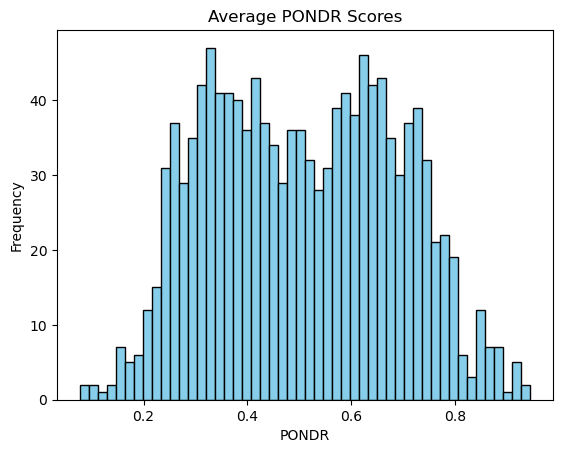

In [18]:
plt.hist(result['PONDR Score'], bins=50, color='skyblue', edgecolor='black')
 
# Adding labels and title
plt.xlabel('PONDR')
plt.ylabel('Frequency')
plt.title('Average PONDR Scores')
 
# Display the plot
plt.show()

In [ ]:
counts_column1 = tf['Annotation Score'].value_counts()
counts_column2 = tf['Existence'].value_counts()

# Create histograms
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.bar(counts_column1.index, counts_column1.values)
plt.grid()
plt.title('Annotation Score')

plt.subplot(1, 2, 2)
plt.bar(counts_column2.index, counts_column2.values)
plt.title('Existence')
plt.xticks(rotation=90)
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(tf['NetCharge'], bins=50, edgecolor='black')
plt.title('Net Charge Distribution')

# Plot histogram for sequence length
tf['SequenceLength'] = tf['Sequence'].apply(len)
plt.subplot(1, 2, 2)
plt.hist(tf['SequenceLength'], bins=50, edgecolor='black')
plt.title('Sequence Length Distribution')

plt.tight_layout()
plt.show()

In [ ]:
unique_domains = tf['Domain'].unique().tolist()
unique_types = df['Type'].unique().tolist()

# Create a new DataFrame from the unique values
unique_df = pd.DataFrame({'Unique Domains': unique_domains, 'Unique Types': unique_types})

# Write the DataFrame to a CSV file
unique_df.to_csv('unique_values.csv', index=False)